In [115]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [116]:
df = pd.read_csv('/content/Hotel Reservations.csv')
df.drop('Booking_ID', axis=1, inplace=True)
df.drop('booking_status', axis=1, inplace=True)  # leakage risk, not a price driver
df.head(10)

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0
5,2,0,0,2,Meal Plan 2,0,Room_Type 1,346,2018,9,13,Online,0,0,0,115.00,1
6,2,0,1,3,Meal Plan 1,0,Room_Type 1,34,2017,10,15,Online,0,0,0,107.55,1
7,2,0,1,3,Meal Plan 1,0,Room_Type 4,83,2018,12,26,Online,0,0,0,105.61,1
8,3,0,0,4,Meal Plan 1,0,Room_Type 1,121,2018,7,6,Offline,0,0,0,96.90,1
9,2,0,0,5,Meal Plan 1,0,Room_Type 4,44,2018,10,18,Online,0,0,0,133.44,3


In [117]:
df.shape

(36275, 17)

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 17 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          36275 non-null  int64  
 1   no_of_children                        36275 non-null  int64  
 2   no_of_weekend_nights                  36275 non-null  int64  
 3   no_of_week_nights                     36275 non-null  int64  
 4   type_of_meal_plan                     36275 non-null  object 
 5   required_car_parking_space            36275 non-null  int64  
 6   room_type_reserved                    36275 non-null  object 
 7   lead_time                             36275 non-null  int64  
 8   arrival_year                          36275 non-null  int64  
 9   arrival_month                         36275 non-null  int64  
 10  arrival_date                          36275 non-null  int64  
 11  market_segment_

In [119]:
df.describe()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000,36275.000000
mean,1.844962,0.105279,0.810724,2.204300,0.030986,85.232557,2017.820427,7.423653,15.596995,0.025637,0.023349,0.153411,103.423539,0.619655
std,0.518715,0.402648,0.870644,1.410905,0.173281,85.930817,0.383836,3.069894,8.740447,0.158053,0.368331,1.754171,35.089424,0.786236
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,17.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.300000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,57.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,99.450000,0.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,126.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,120.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


In [120]:
df.isnull().sum()

,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0
arrival_month,0


In [121]:
# No missing values, but some rows have avg_price_per_room = 0 (likely comp bookings)
df = df[df['avg_price_per_room'] > 0]
df.isnull().sum()

,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0
arrival_month,0


In [122]:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0


In [123]:
df.columns

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'room_type_reserved', 'lead_time', 'arrival_year', 'arrival_month',
       'arrival_date', 'market_segment_type', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests'],
      dtype='object')

In [124]:
print(df['type_of_meal_plan'].unique())
print(df['room_type_reserved'].unique())
print(df['market_segment_type'].unique())

['Meal Plan 1' 'Not Selected' 'Meal Plan 2' 'Meal Plan 3']
['Room_Type 1' 'Room_Type 4' 'Room_Type 2' 'Room_Type 6' 'Room_Type 5'
 'Room_Type 7' 'Room_Type 3']
['Offline' 'Online' 'Corporate' 'Aviation' 'Complementary']


In [125]:
numeric_columns = ['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
                    'no_of_week_nights', 'lead_time', 'arrival_year',
                    'arrival_month', 'arrival_date', 'no_of_previous_cancellations',
                    'no_of_previous_bookings_not_canceled', 'no_of_special_requests']

categorical_columns = ['type_of_meal_plan', 'room_type_reserved',
                        'market_segment_type', 'required_car_parking_space',
                        'repeated_guest']

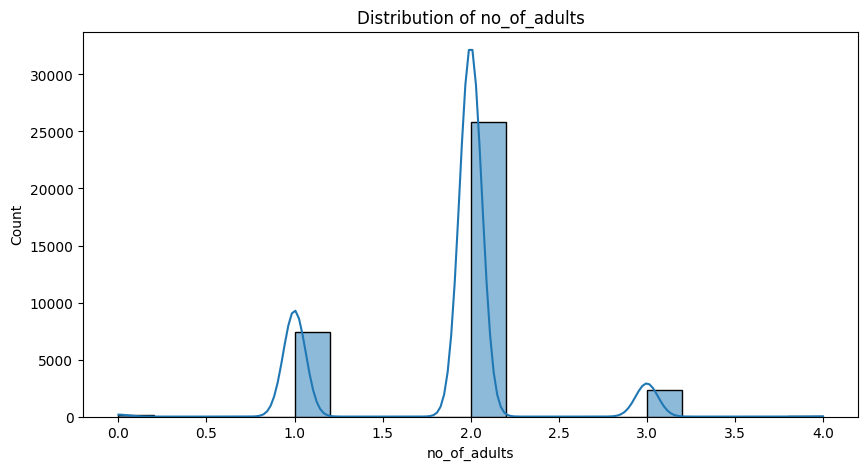

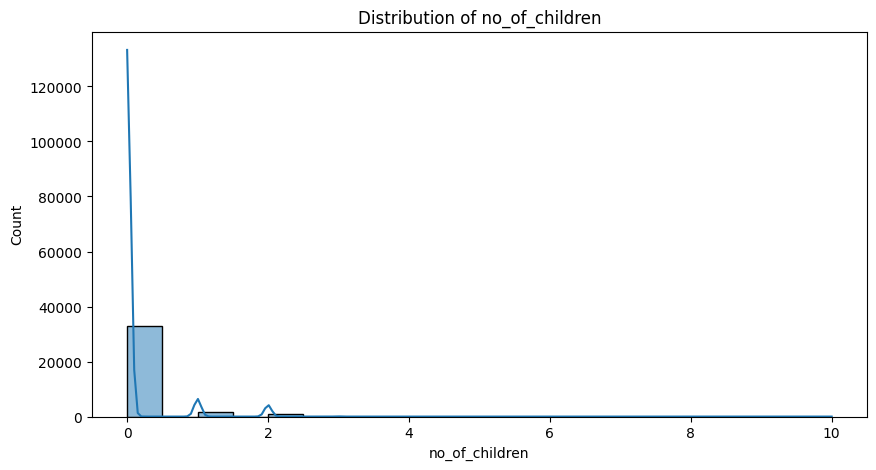

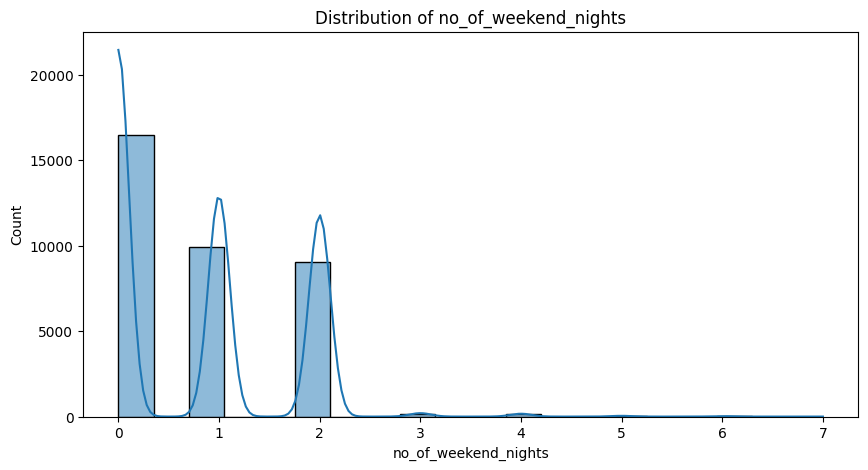

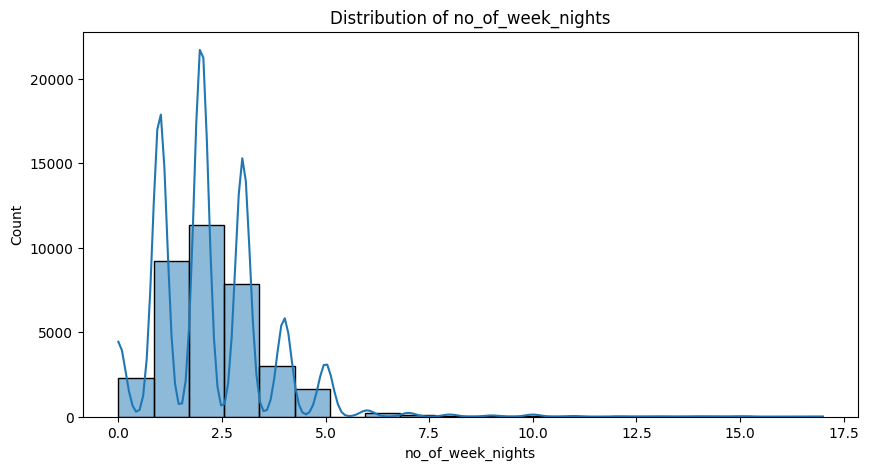

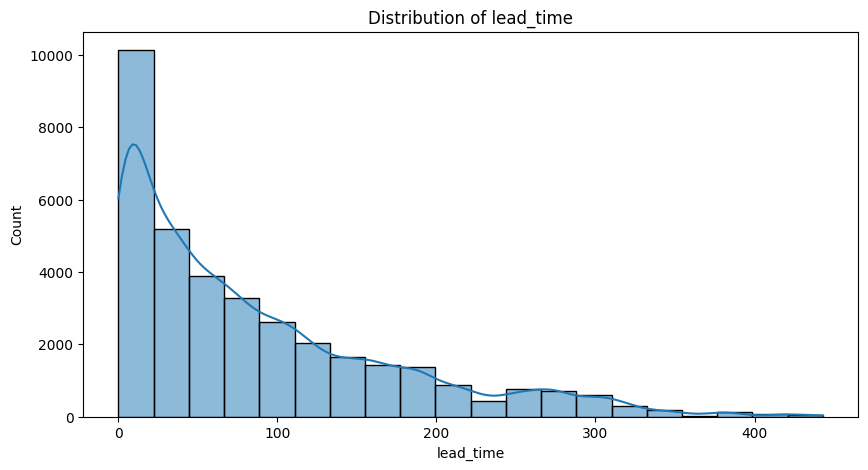

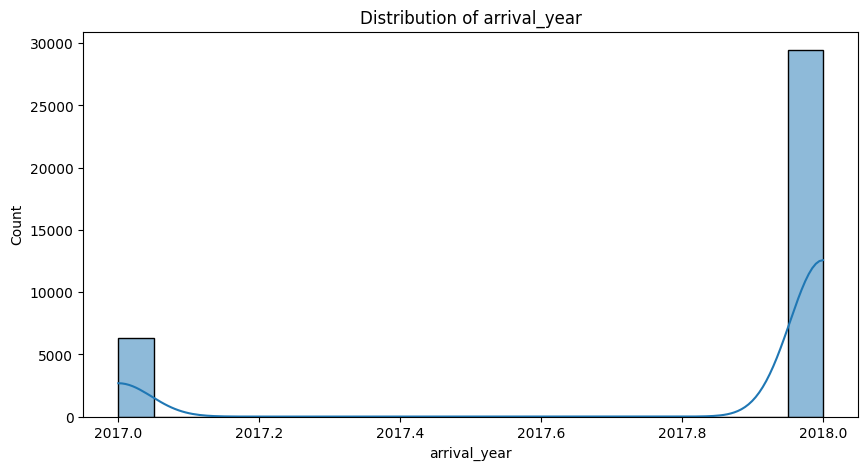

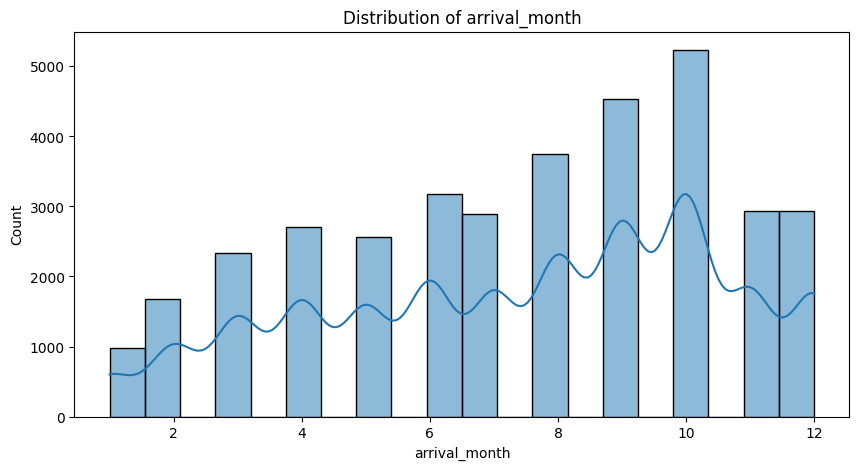

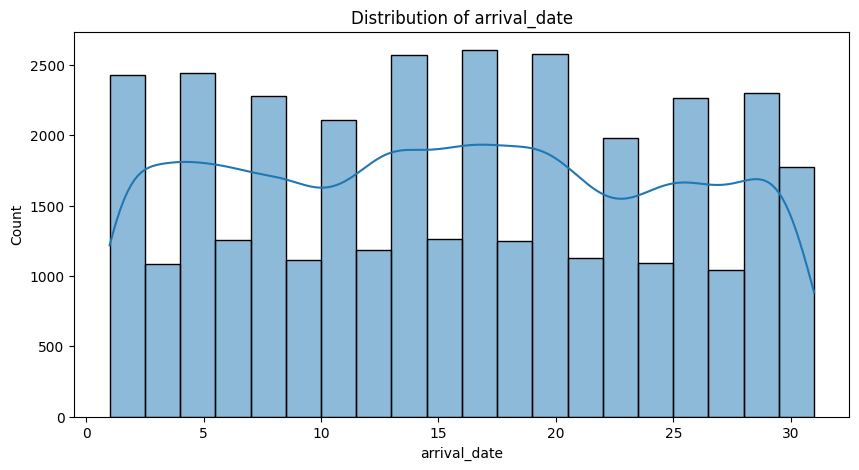

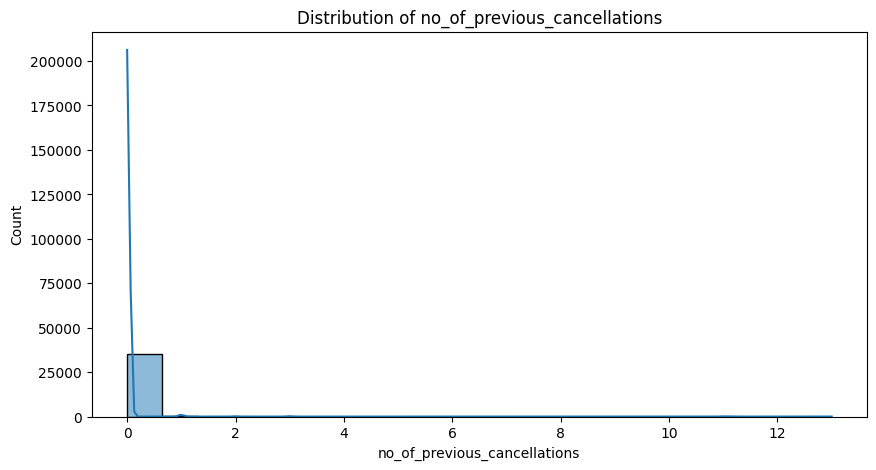

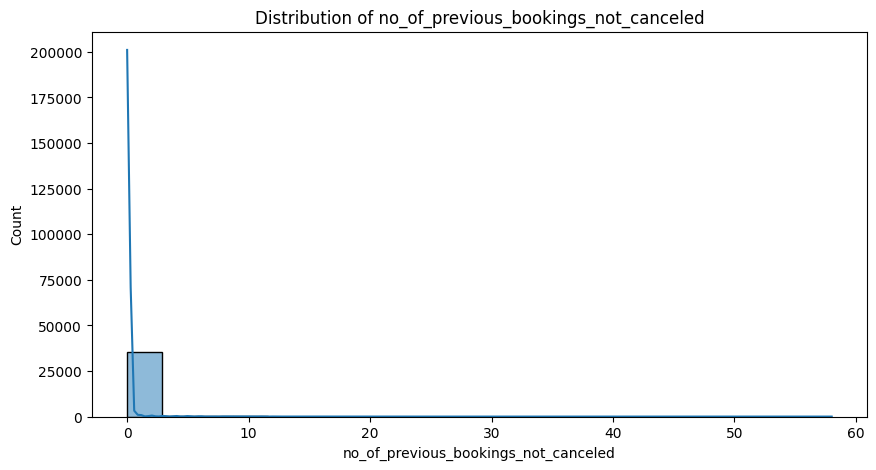

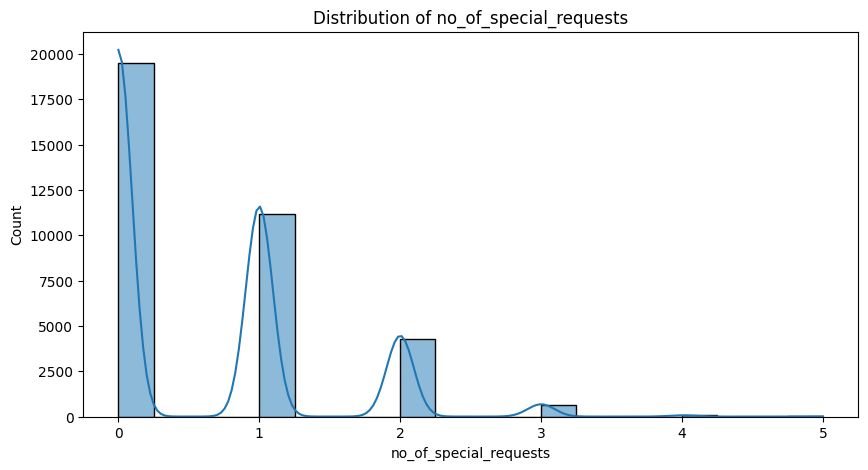

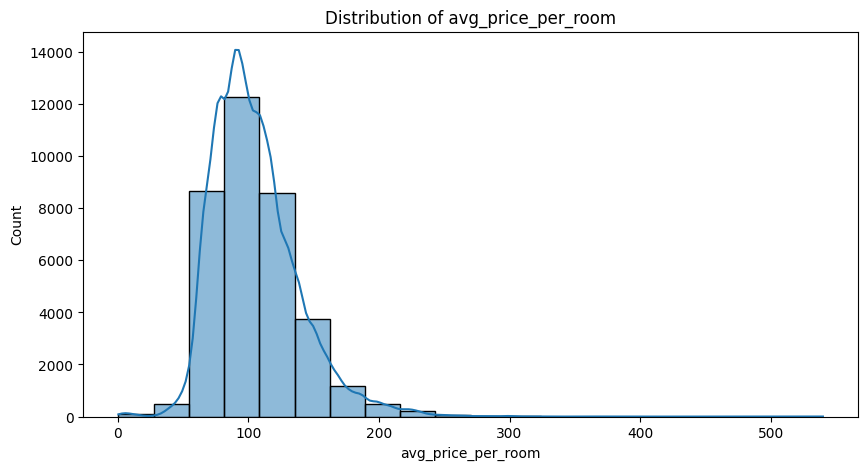

In [126]:
for col in numeric_columns + ['avg_price_per_room']:
  plt.figure(figsize=(10,5))
  sns.histplot(df[col], kde=True, bins=20)
  plt.title(f'Distribution of {col}')
  plt.show()

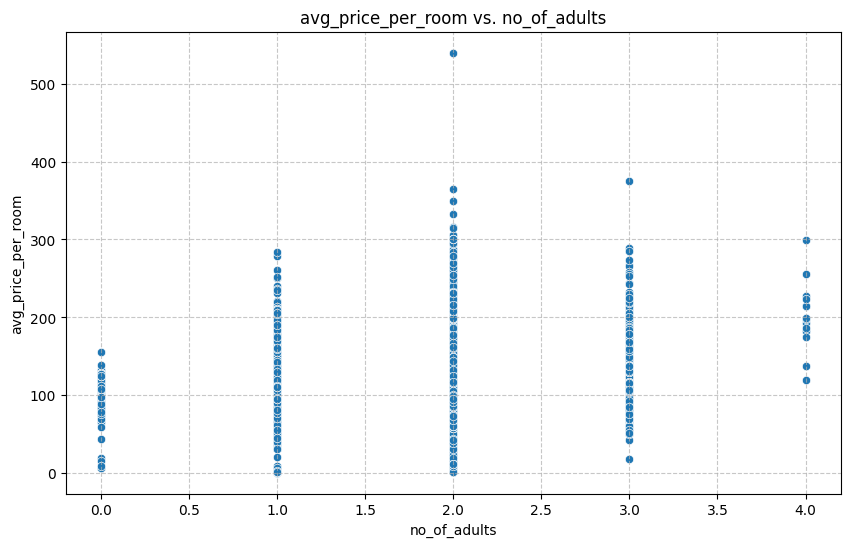

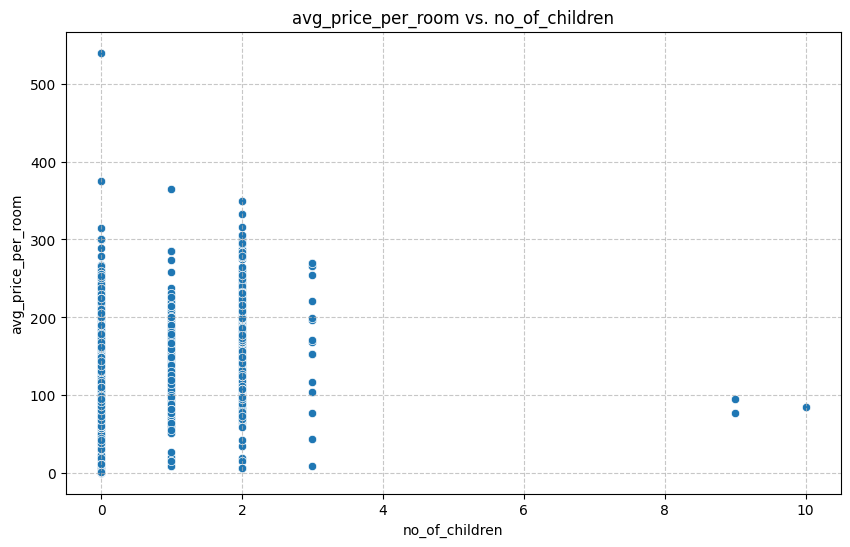

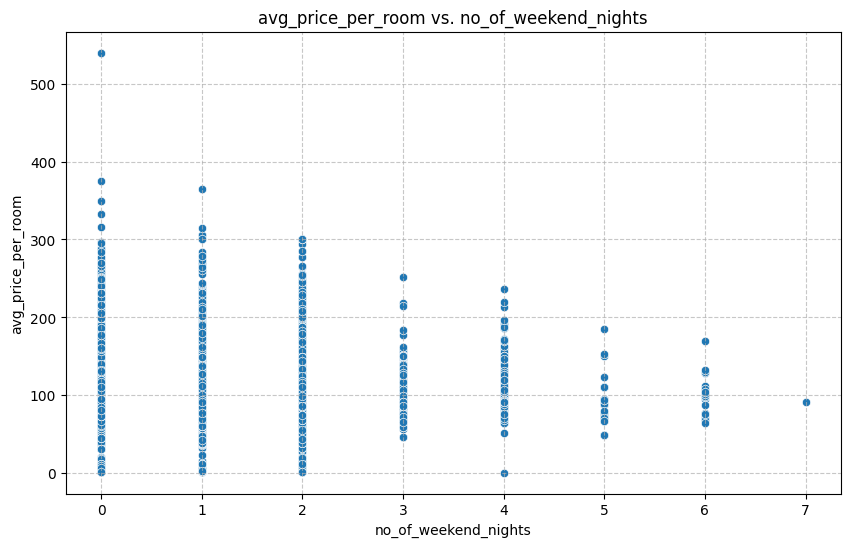

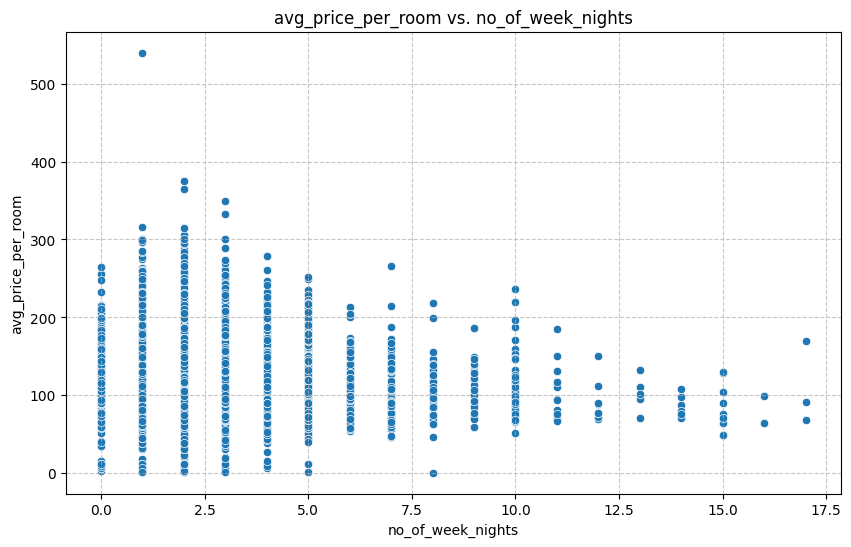

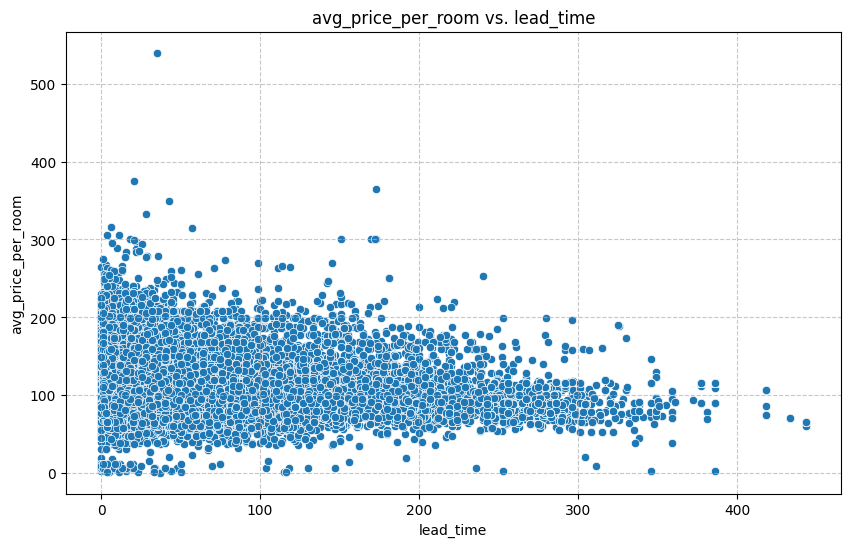

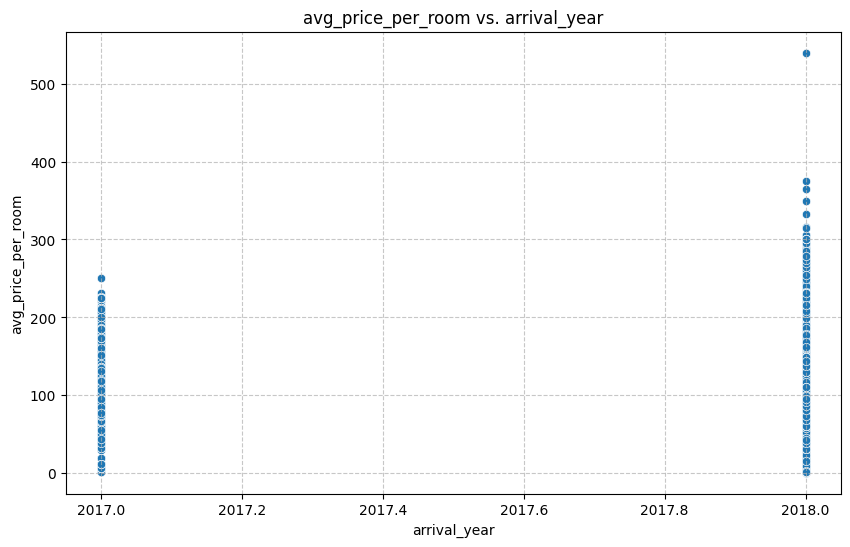

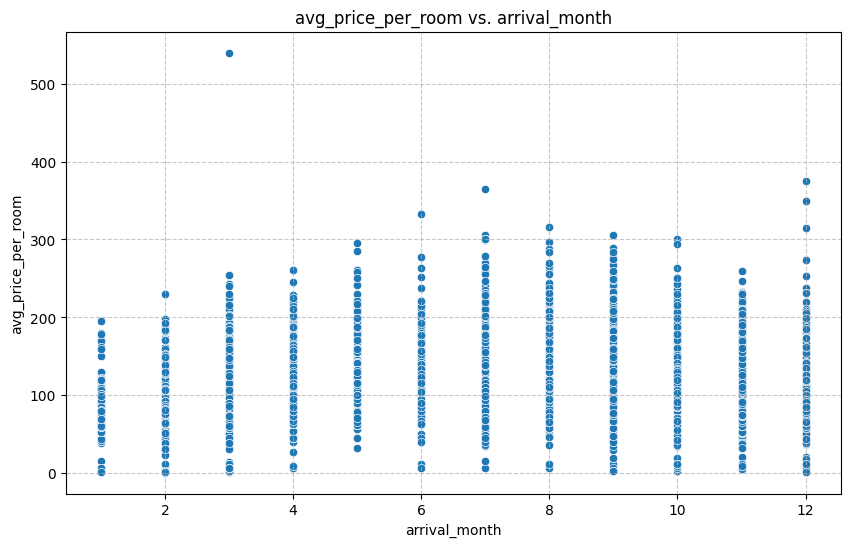

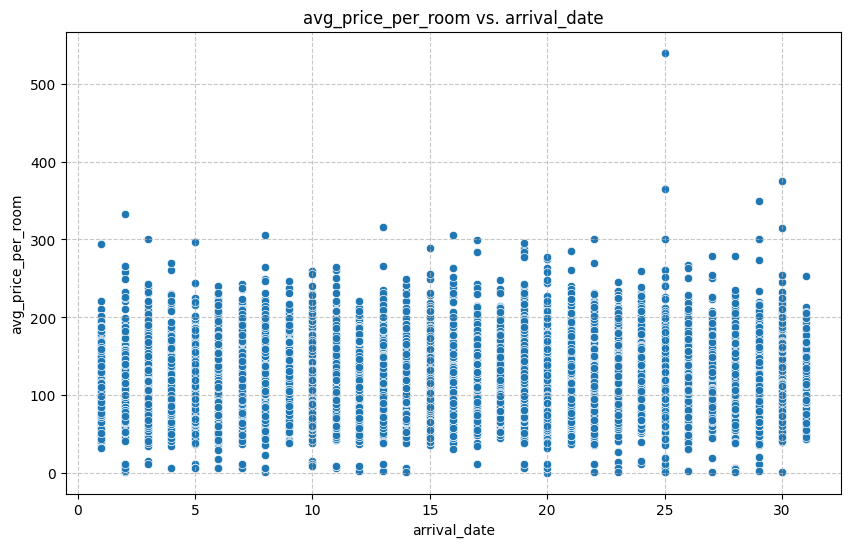

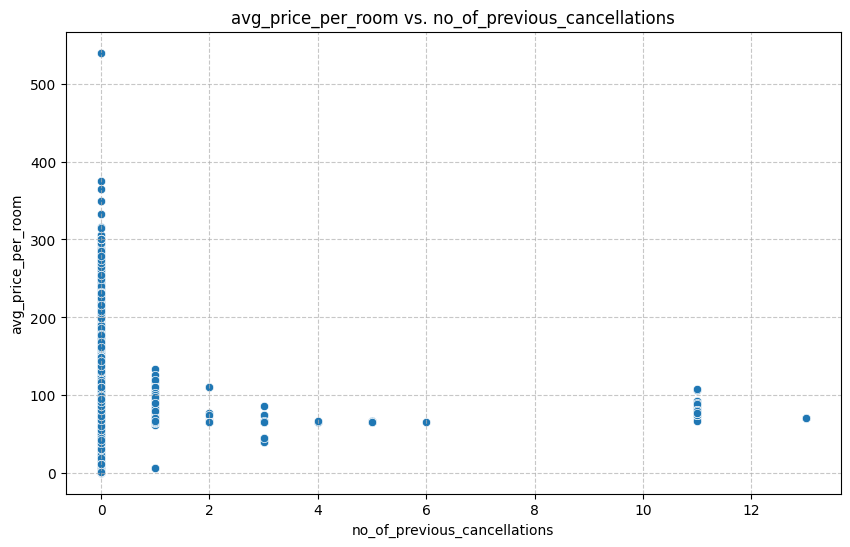

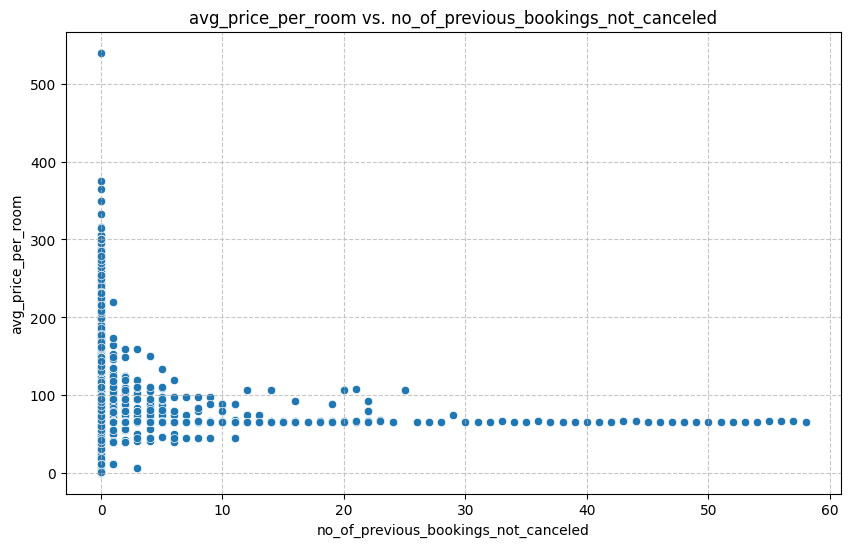

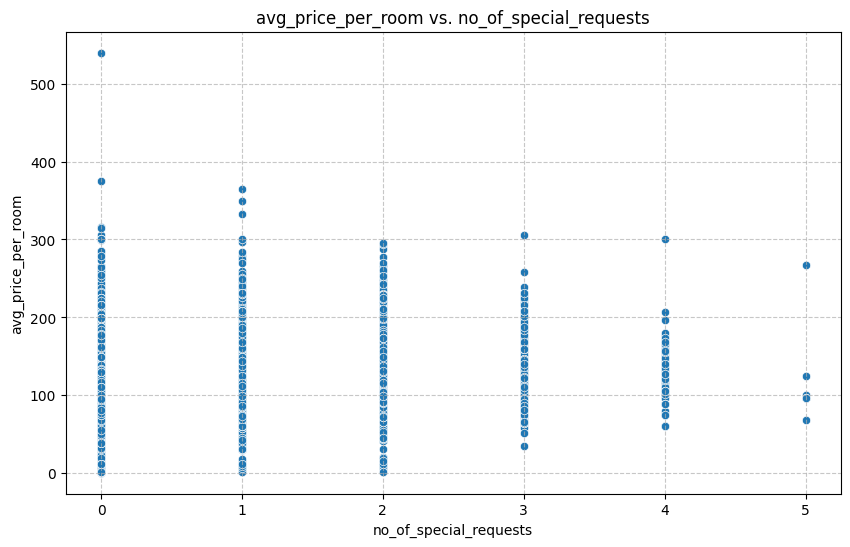

In [127]:
for col in numeric_columns:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=col, y='avg_price_per_room', data=df)
    plt.title(f'avg_price_per_room vs. {col}')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

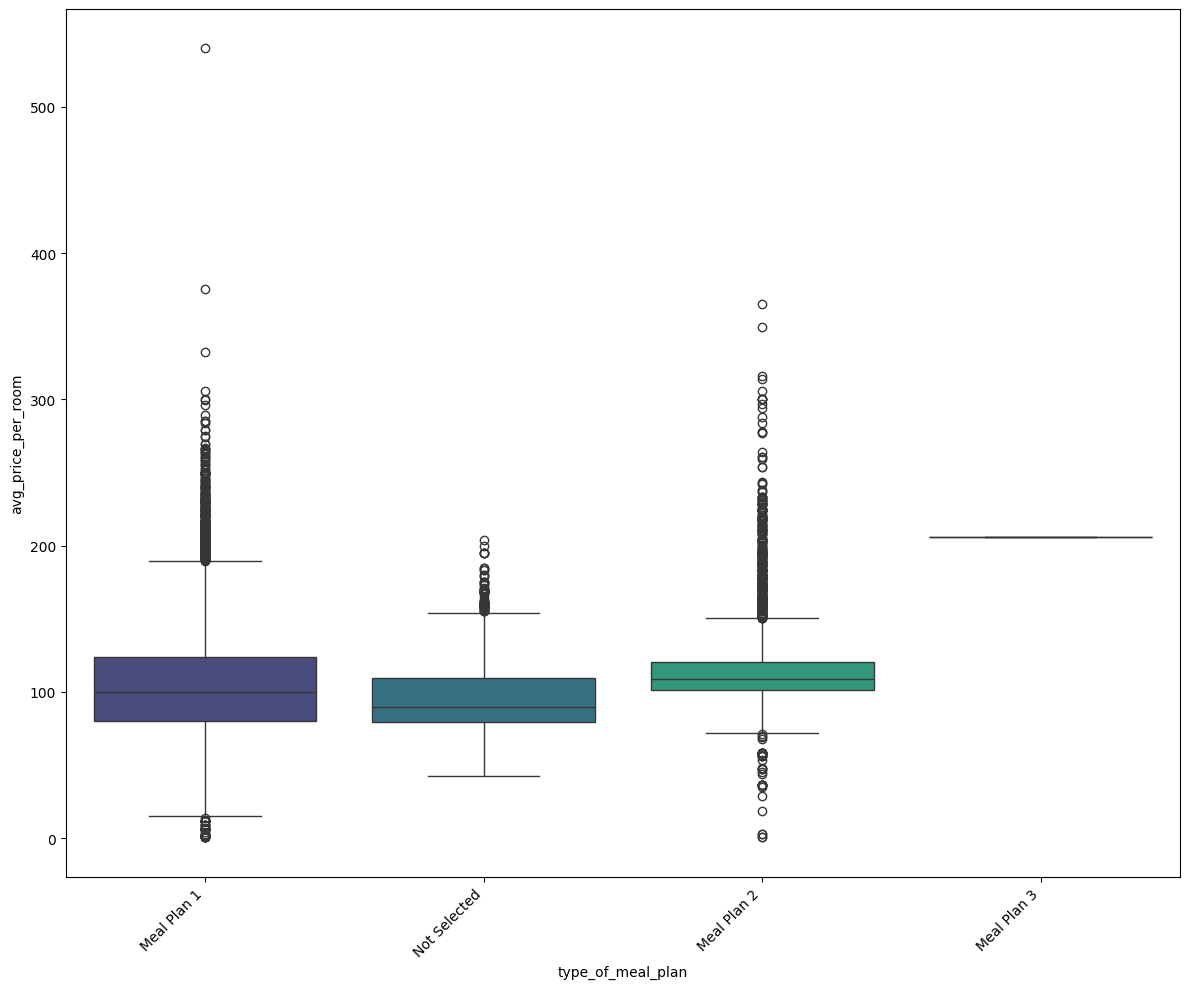

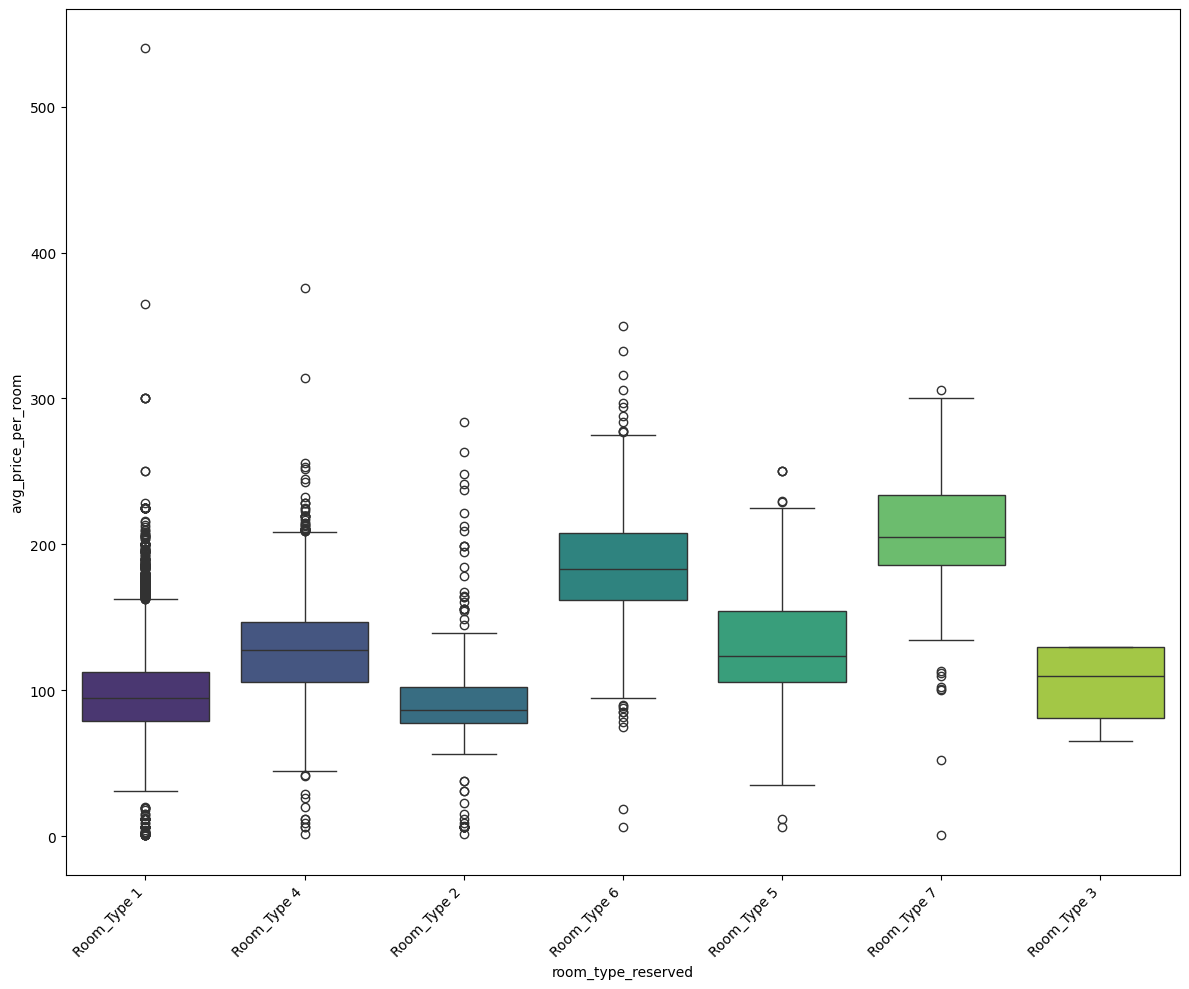

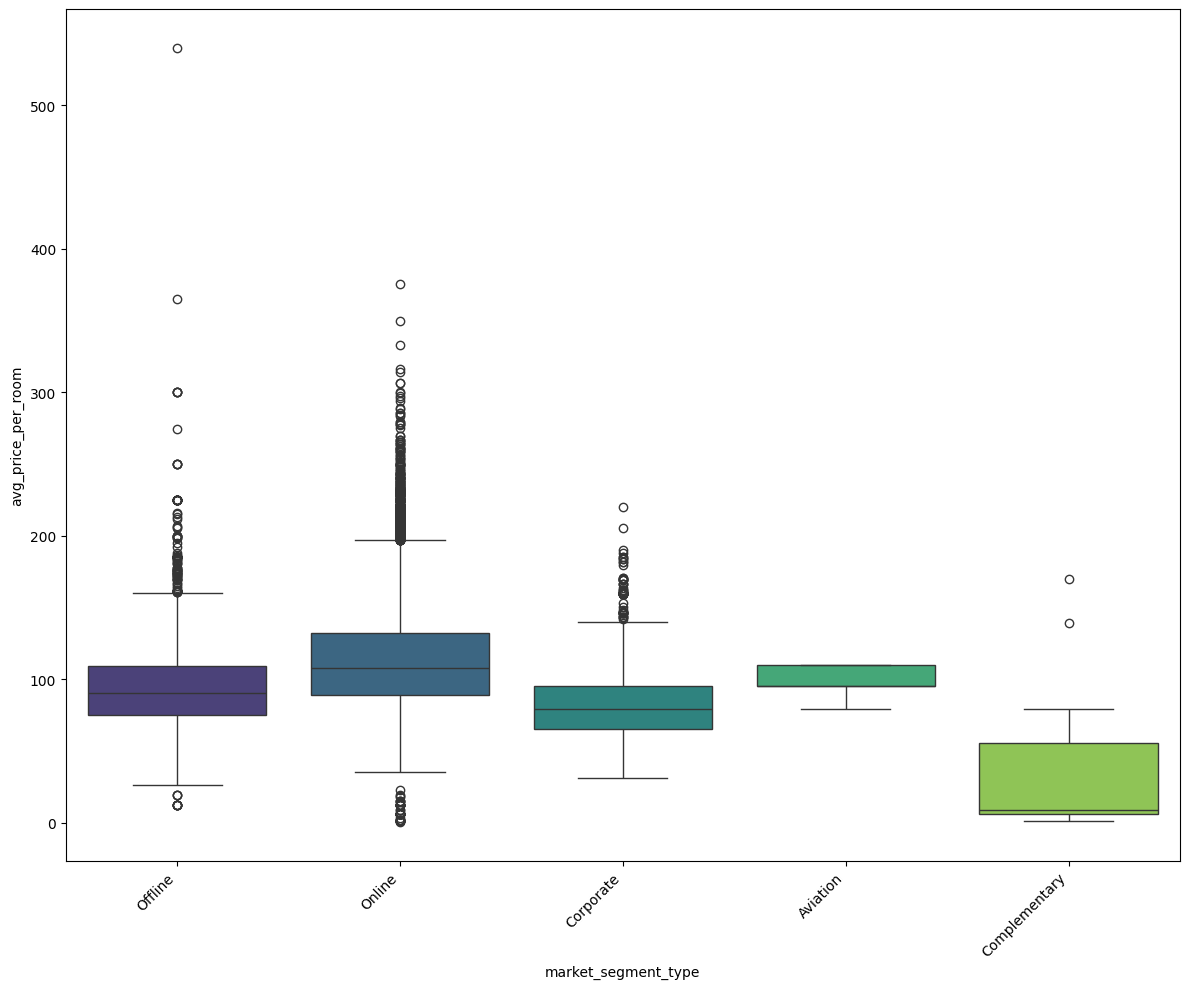

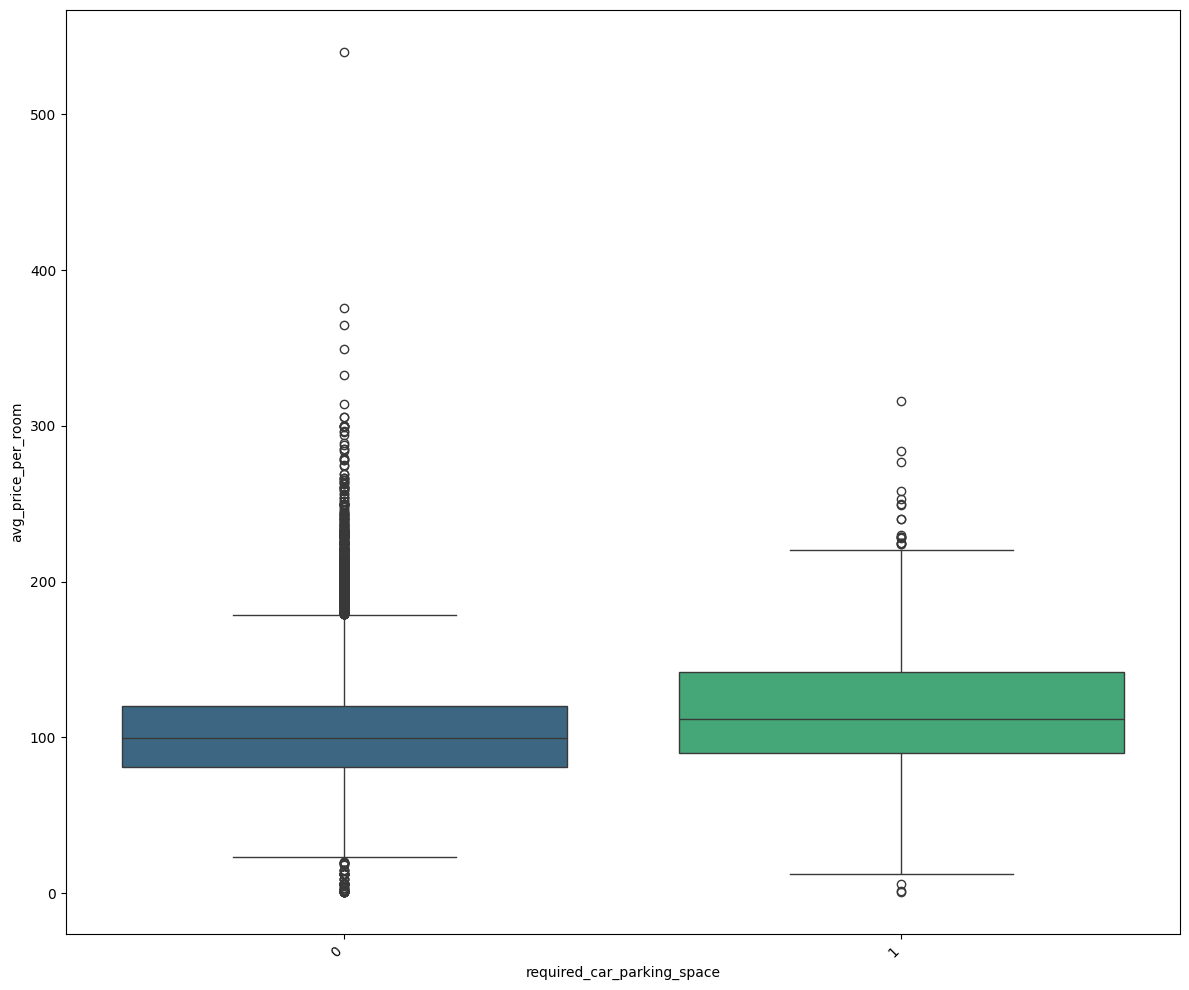

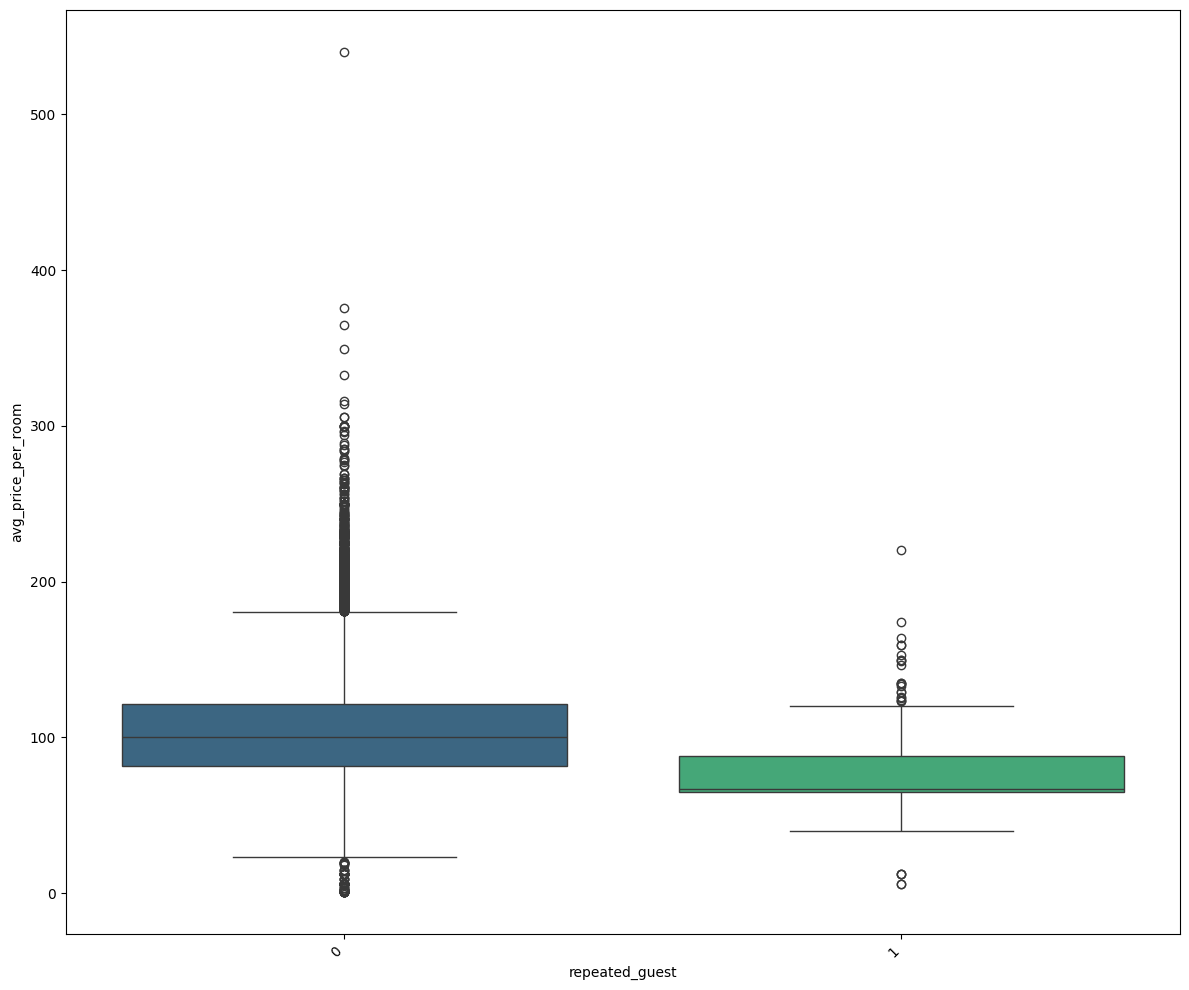

In [128]:
for col in categorical_columns:
    plt.figure(figsize=(12, 10))
    sns.boxplot(x=col, y='avg_price_per_room', data=df, palette='viridis')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

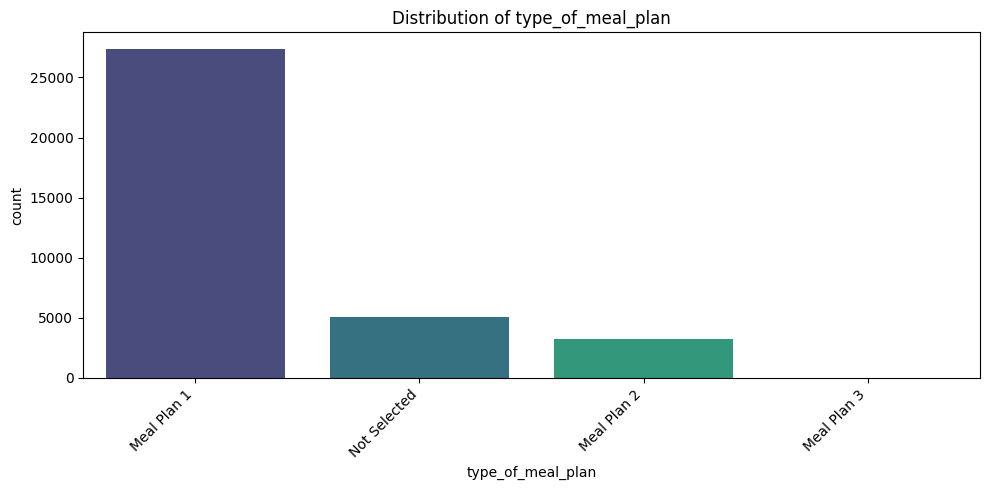

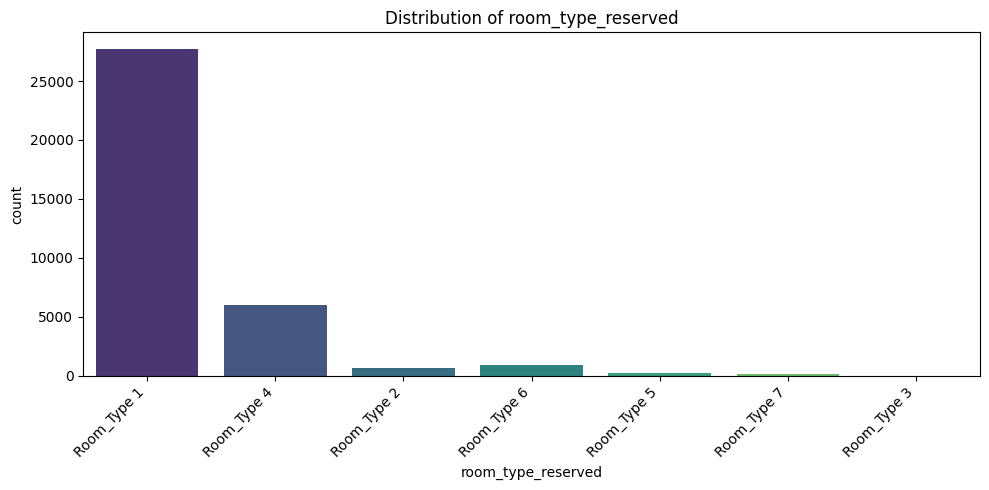

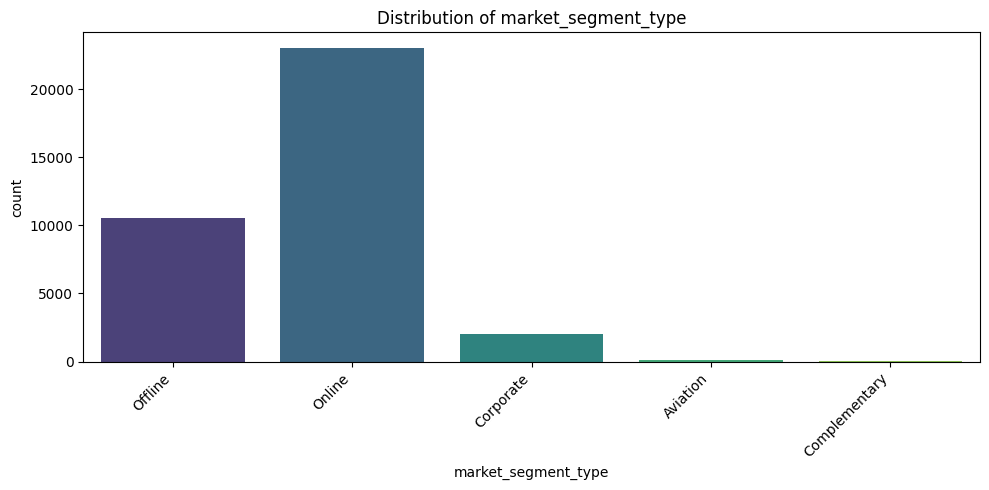

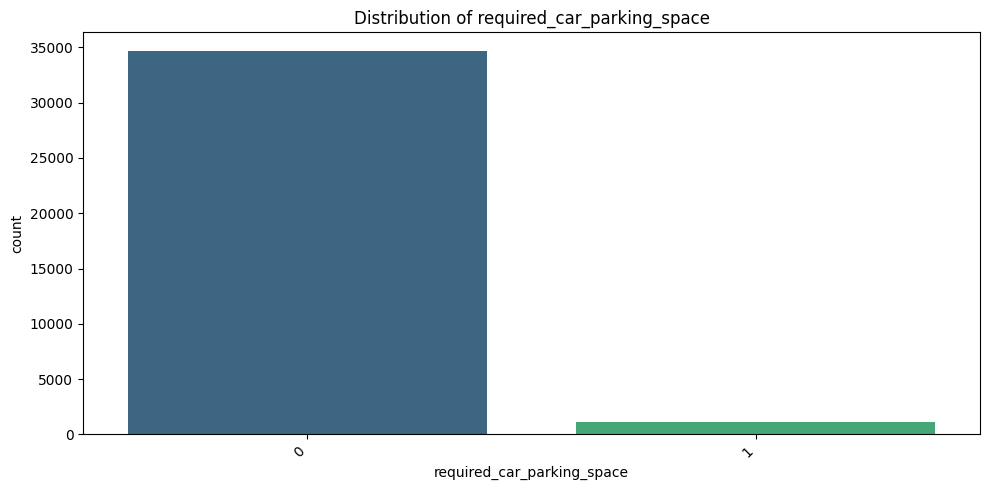

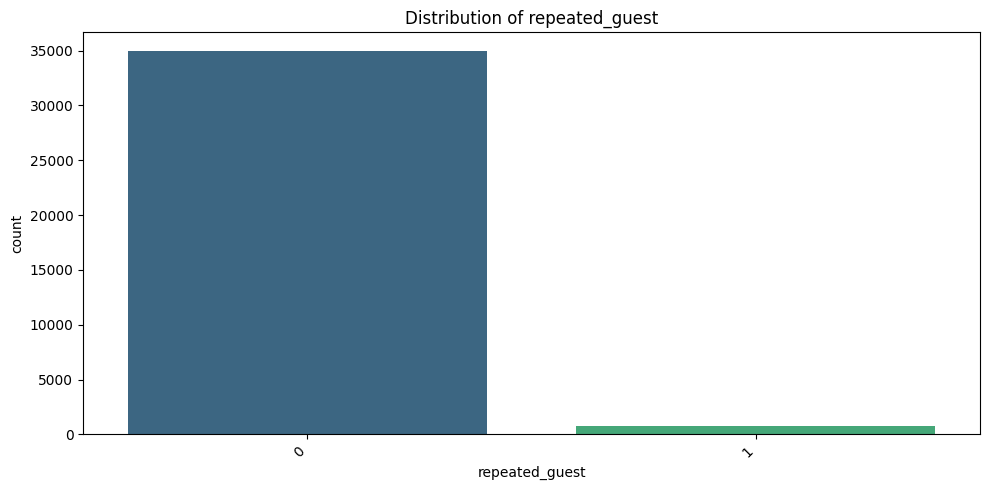

In [129]:
for col in categorical_columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col, palette='viridis')
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

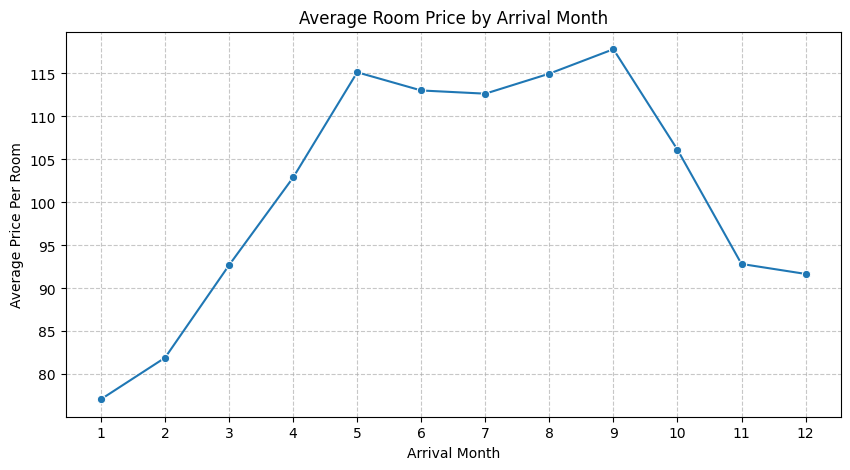

In [130]:
# SEASONALITY: AVG PRICE PER MONTH
monthly_avg_price = df.groupby('arrival_month')['avg_price_per_room'].mean().sort_index()

plt.figure(figsize=(10, 5))
sns.lineplot(x=monthly_avg_price.index, y=monthly_avg_price.values, marker='o')
plt.title('Average Room Price by Arrival Month')
plt.xlabel('Arrival Month')
plt.ylabel('Average Price Per Room')
plt.xticks(range(1, 13))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

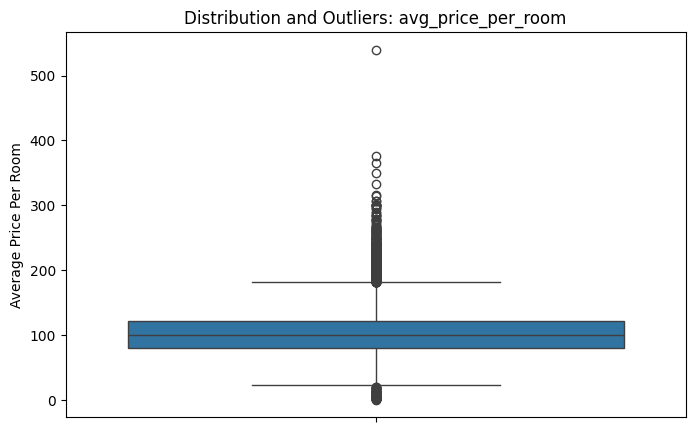

In [131]:
#TARGET VARIABLE OUTLIER CHECK
plt.figure(figsize=(8, 5))
sns.boxplot(y=df['avg_price_per_room'])
plt.title('Distribution and Outliers: avg_price_per_room')
plt.ylabel('Average Price Per Room')
plt.show()

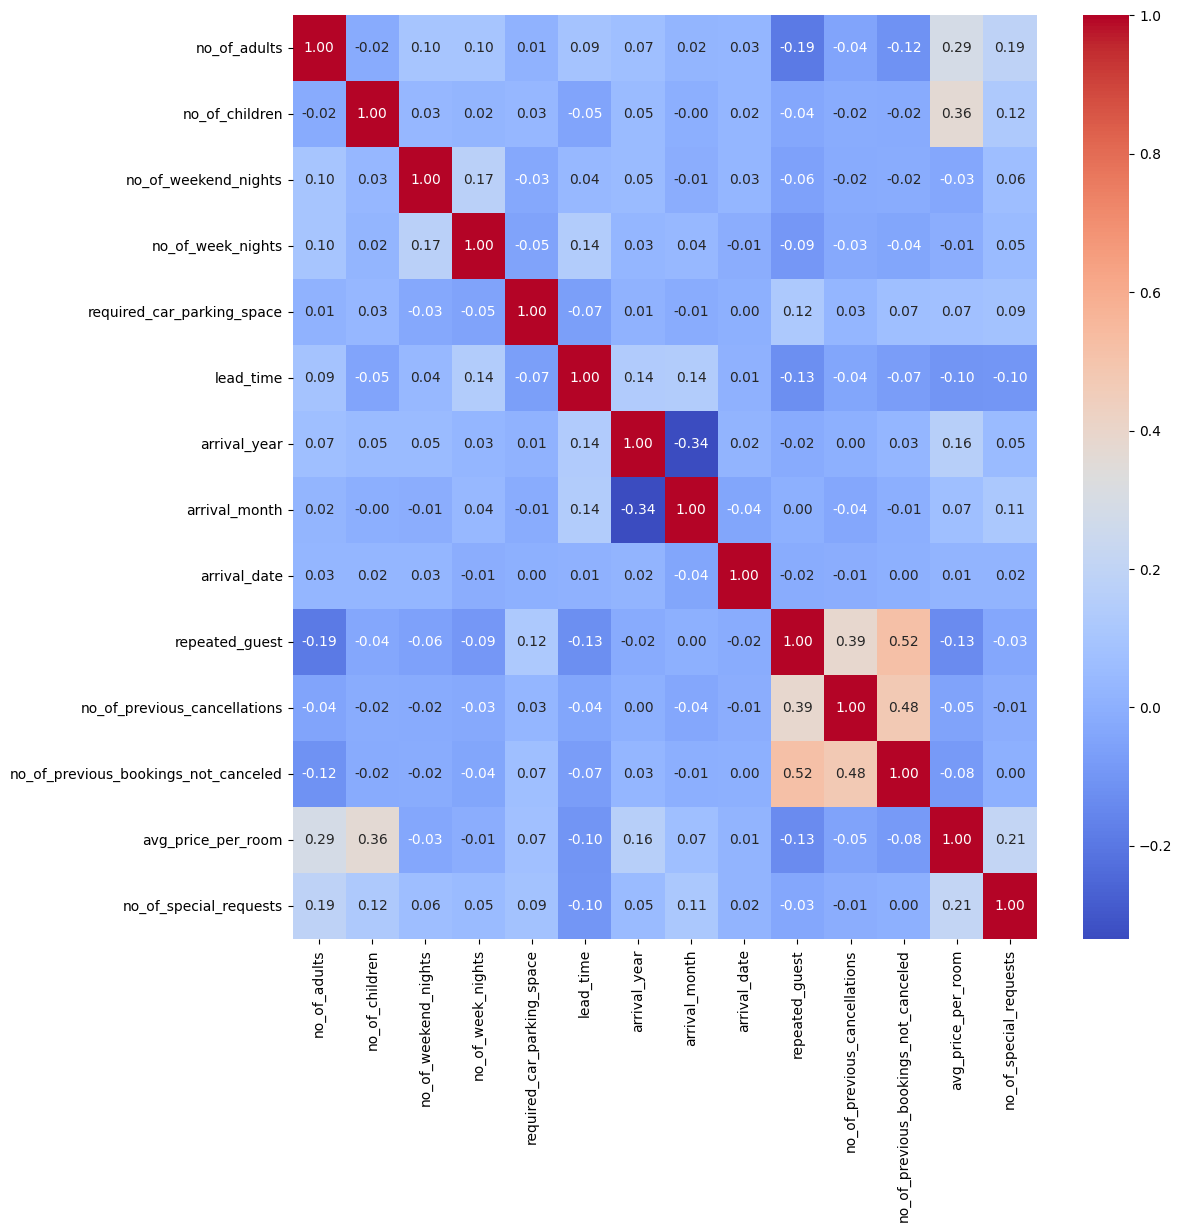

In [132]:
plt.figure(figsize=(12,12))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [133]:
from sklearn.model_selection import train_test_split

# Split BEFORE any feature-selection diagnostics, so Pearson/chi-square/VIF
# decisions are made using training data only — no test-set leakage into feature choice
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

In [134]:
from scipy.stats import pearsonr, chi2_contingency
pearson_results = []
for col in numeric_columns:
    r, p = pearsonr(train_df[col], train_df['avg_price_per_room'])
    decision = 'Keep' if abs(r) >= 0.05 else 'Not Keep'
    pearson_results.append({'Feature': col, 'Pearson_r': round(r, 4), 'p-value': p,'Decision': decision})

pearson_df = pd.DataFrame(pearson_results)
pearson_df

## Note: with n=36,275, p-values are near-zero for almost every feature (even trivial
## correlations are "significant"), so p-value hypothesis testing isn't a useful filter here.
## Decision rule instead: drop features with |Pearson_r| < 0.05, since these correlations
## are too small to be practically meaningful regardless of statistical significance.
## This removes: no_of_weekend_nights, no_of_week_nights, arrival_date, no_of_previous_cancellations


,Feature,Pearson_r,p-value,Decision
0,no_of_adults,0.2886,0.000000e+00,Keep
1,no_of_children,0.3705,0.000000e+00,Keep
2,no_of_weekend_nights,-0.0359,1.224042e-09,Not Keep
3,no_of_week_nights,-0.0124,3.582829e-02,Not Keep
4,lead_time,-0.1021,4.006731e-67,Keep
5,arrival_year,0.1649,2.741753e-173,Keep
6,arrival_month,0.0648,5.051305e-28,Keep
7,arrival_date,0.0184,1.836033e-03,Not Keep
8,no_of_previous_cancellations,-0.0501,2.443151e-17,Keep
9,no_of_previous_bookings_not_canceled,-0.0818,1.176673e-43,Keep


In [135]:
train_df['price_bin'] = pd.qcut(train_df['avg_price_per_room'], q=4, labels=['Low','Medium','High','Very High'])

chi2_results = []
for col in categorical_columns:
    contingency = pd.crosstab(train_df[col], train_df['price_bin'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    decision = 'Keep' if p < 0.05 else 'Not Keep'
    chi2_results.append({
        'Feature': col,
        'Chi2_Statistic': round(chi2, 2),
        'p_value': p,
        'Decision': decision
    })

chi2_df = pd.DataFrame(chi2_results)
chi2_df

,Feature,Chi2_Statistic,p_value,Decision
0,type_of_meal_plan,1820.79,0.000000e+00,Keep
1,room_type_reserved,6992.49,0.000000e+00,Keep
2,market_segment_type,4325.36,0.000000e+00,Keep
3,required_car_parking_space,127.47,1.895385e-27,Keep
4,repeated_guest,845.68,5.368518e-183,Keep


FEATURE ENGINEERING AND STANDARIZATION

In [136]:
weak_numeric_cols = pearson_df.loc[pearson_df['Decision'] == 'Not Keep', 'Feature'].tolist()
print("Dropping (Pearson 'Not Keep'):", weak_numeric_cols)

train_df = train_df.drop(columns=weak_numeric_cols + ['price_bin'])
test_df = test_df.drop(columns=weak_numeric_cols)

train_encoded = pd.get_dummies(train_df, drop_first=True).astype(float)
test_encoded = pd.get_dummies(test_df, drop_first=True).astype(float)

# Align test columns to train's dummy columns (handles rare categories not seen in one split)
test_encoded = test_encoded.reindex(columns=train_encoded.columns, fill_value=0)

train_encoded.head()

Dropping (Pearson 'Not Keep'): ['no_of_weekend_nights', 'no_of_week_nights', 'arrival_date']


,no_of_adults,no_of_children,required_car_parking_space,lead_time,arrival_year,arrival_month,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,...,room_type_reserved_Room_Type 2,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online
0,2.0,0.0,0.0,113.0,2018.0,12.0,0.0,0.0,0.0,90.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,2.0,0.0,0.0,5.0,2018.0,11.0,0.0,0.0,0.0,106.21,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,1.0,0.0,0.0,107.0,2017.0,7.0,0.0,0.0,0.0,52.36,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,4.0,2017.0,10.0,0.0,0.0,0.0,65.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,2.0,0.0,0.0,275.0,2018.0,10.0,0.0,0.0,0.0,106.20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [137]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def calculate_vif(x):
    vif_data = pd.DataFrame()
    vif_data['Feature'] = x.columns
    vif_data['VIF'] = [variance_inflation_factor(x.values, i) for i in range(x.shape[1])]
    return vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

x_vif = train_encoded.drop('avg_price_per_room', axis=1)
threshold = 10
dropped_cols = []

while True:
    vif_table = calculate_vif(x_vif)
    max_vif = vif_table['VIF'].max()
    if max_vif > threshold:
        worst_feature = vif_table.loc[vif_table['VIF'].idxmax(), 'Feature']
        dropped_cols.append((worst_feature, max_vif))
        x_vif = x_vif.drop(columns=[worst_feature])
    else:
        break

print("Columns dropped due to multicollinearity (VIF > 10):")
for col, vif in dropped_cols:
    print(f"  {col}: VIF = {vif:.2f}")

print("\nFinal VIF table:")
calculate_vif(x_vif)

Columns dropped due to multicollinearity (VIF > 10):
  arrival_year: VIF = 300.13
  no_of_adults: VIF = 17.69

Final VIF table:


,Feature,VIF
0,arrival_month,6.984108
1,market_segment_type_Online,6.539168
2,market_segment_type_Offline,3.316771
3,lead_time,2.376049
4,no_of_children,2.167518
5,no_of_special_requests,2.000464
6,room_type_reserved_Room_Type 6,1.965557
7,repeated_guest,1.730405
8,market_segment_type_Corporate,1.619589
9,no_of_previous_bookings_not_canceled,1.608732


In [138]:
final_features = x_vif.columns.tolist()

train_encoded = train_encoded[final_features + ['avg_price_per_room']]
test_encoded = test_encoded[final_features + ['avg_price_per_room']]

train_encoded.head()

,no_of_children,required_car_parking_space,lead_time,arrival_month,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,no_of_special_requests,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Meal Plan 3,...,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online,avg_price_per_room
0,0.0,0.0,113.0,12.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,90.00
1,0.0,0.0,5.0,11.0,0.0,0.0,0.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,106.21
2,0.0,0.0,107.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,52.36
3,0.0,0.0,4.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,65.00
4,0.0,0.0,275.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,106.20


In [139]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error

In [140]:
from sklearn.preprocessing import StandardScaler

x_train = train_encoded.drop('avg_price_per_room', axis=1)
y_train = train_encoded['avg_price_per_room']
x_test = test_encoded.drop('avg_price_per_room', axis=1)
y_test = test_encoded['avg_price_per_room']

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [141]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
}

In [142]:
results = []

In [143]:
for name, model in models.items():
  model.fit(x_train_scaled, y_train)
  y_pred = model.predict(x_test_scaled)
  mse = mean_squared_error(y_test, y_pred)
  rmse = root_mean_squared_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  results.append({'Model': name, 'MSE': mse, 'RMSE': rmse, 'R2 Score': r2})

In [144]:
results ##XGBoost gives the least rmse

[{'Model': 'Linear Regression',
  'MSE': 587.7653249066819,
  'RMSE': 24.243871904188115,
  'R2 Score': 0.43383201496369084},
 {'Model': 'Decision Tree',
  'MSE': 453.0552891483379,
  'RMSE': 21.285095469561274,
  'R2 Score': 0.5635921526880109},
 {'Model': 'Random Forest',
  'MSE': 352.72067551824165,
  'RMSE': 18.780859285939012,
  'R2 Score': 0.6602399874975367},
 {'Model': 'XGBoost',
  'MSE': 337.6570023635552,
  'RMSE': 18.375445637141844,
  'R2 Score': 0.6747501484679689}]

In [145]:
final_model = XGBRegressor(random_state=42)
final_model.fit(x_train_scaled, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

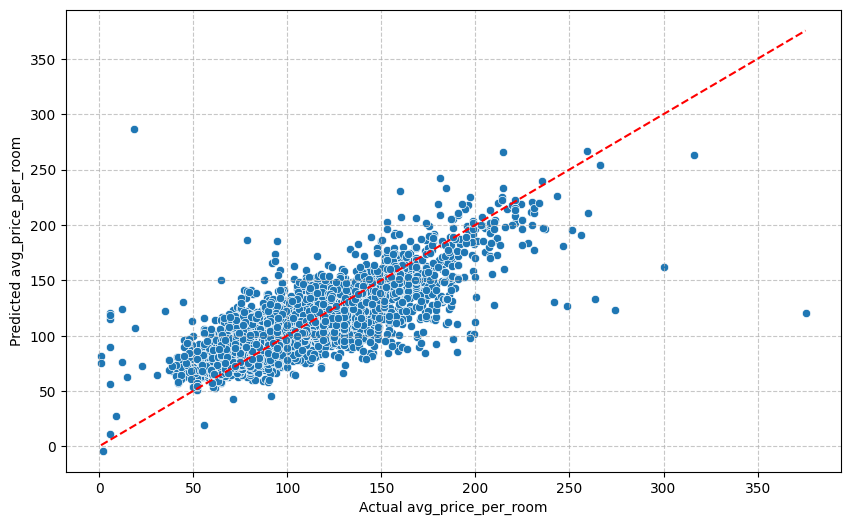

In [146]:
y_pred_test = final_model.predict(x_test_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_test)
plt.xlabel('Actual avg_price_per_room')
plt.ylabel('Predicted avg_price_per_room')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

PREDICTIVE SYSTEM


In [147]:
x_train.columns

Index(['no_of_children', 'required_car_parking_space', 'lead_time',
       'arrival_month', 'repeated_guest', 'no_of_previous_cancellations',
       'no_of_previous_bookings_not_canceled', 'no_of_special_requests',
       'type_of_meal_plan_Meal Plan 2', 'type_of_meal_plan_Meal Plan 3',
       'type_of_meal_plan_Not Selected', 'room_type_reserved_Room_Type 2',
       'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4',
       'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6',
       'room_type_reserved_Room_Type 7', 'market_segment_type_Complementary',
       'market_segment_type_Corporate', 'market_segment_type_Offline',
       'market_segment_type_Online'],
      dtype='object')

In [148]:
train_encoded.columns

Index(['no_of_children', 'required_car_parking_space', 'lead_time',
       'arrival_month', 'repeated_guest', 'no_of_previous_cancellations',
       'no_of_previous_bookings_not_canceled', 'no_of_special_requests',
       'type_of_meal_plan_Meal Plan 2', 'type_of_meal_plan_Meal Plan 3',
       'type_of_meal_plan_Not Selected', 'room_type_reserved_Room_Type 2',
       'room_type_reserved_Room_Type 3', 'room_type_reserved_Room_Type 4',
       'room_type_reserved_Room_Type 5', 'room_type_reserved_Room_Type 6',
       'room_type_reserved_Room_Type 7', 'market_segment_type_Complementary',
       'market_segment_type_Corporate', 'market_segment_type_Offline',
       'market_segment_type_Online', 'avg_price_per_room'],
      dtype='object')

In [149]:
train_encoded.head()

,no_of_children,required_car_parking_space,lead_time,arrival_month,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,no_of_special_requests,type_of_meal_plan_Meal Plan 2,type_of_meal_plan_Meal Plan 3,...,room_type_reserved_Room_Type 3,room_type_reserved_Room_Type 4,room_type_reserved_Room_Type 5,room_type_reserved_Room_Type 6,room_type_reserved_Room_Type 7,market_segment_type_Complementary,market_segment_type_Corporate,market_segment_type_Offline,market_segment_type_Online,avg_price_per_room
0,0.0,0.0,113.0,12.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,90.00
1,0.0,0.0,5.0,11.0,0.0,0.0,0.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,106.21
2,0.0,0.0,107.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,52.36
3,0.0,0.0,4.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,65.00
4,0.0,0.0,275.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,106.20


In [150]:
#new_data = pd.DataFrame({col: [1] for col in x.columns})
# manually set the values for your test booking
new_data = pd.DataFrame({
    'no_of_children': [0],
    'required_car_parking_space': [0],
    'lead_time': [224],
    'arrival_month': [10],
    'repeated_guest':[0],
    'no_of_previous_cancellations': [0],
    'no_of_previous_bookings_not_canceled': [0],
    'no_of_special_requests': [0],
    'type_of_meal_plan_Meal Plan 2': [0],
    'type_of_meal_plan_Meal Plan 3': [0],
    'type_of_meal_plan_Not Selected': [0],
    'room_type_reserved_Room_Type 2': [0],
    'room_type_reserved_Room_Type 3': [0],
    'room_type_reserved_Room_Type 4': [0],
    'room_type_reserved_Room_Type 5': [0],
    'room_type_reserved_Room_Type 6': [0],
    'room_type_reserved_Room_Type 7': [0],
    'market_segment_type_Complementary': [0],
    'market_segment_type_Corporate': [0],
    'market_segment_type_Offline': [1],
    'market_segment_type_Online': [0]
})

#

new_data_scaled = scaler.transform(new_data)
predicted_price = final_model.predict(new_data_scaled)
print(f"Predicted Average Price Per Room: {predicted_price[0]:.2f}")

Predicted Average Price Per Room: 70.07


APPLYING RIDGE AND LASSO REGRESSION

In [151]:
from sklearn.linear_model import RidgeCV, LassoCV
import numpy as np

# Test a range of alpha values on a log scale
alphas = np.logspace(-3, 3, 50)

ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(x_train_scaled, y_train)

lasso_cv = LassoCV(alphas=alphas, cv=5, max_iter=10000)
lasso_cv.fit(x_train_scaled, y_train)

print("Best Ridge alpha:", ridge_cv.alpha_)
print("Best Lasso alpha:", lasso_cv.alpha_)

Best Ridge alpha: 25.595479226995334
Best Lasso alpha: 0.012648552168552958


Get predictions, RMSE/R², and compare coefficients side by side

In [152]:
# Predictions
ridge_pred = ridge_cv.predict(x_test_scaled)
lasso_pred = lasso_cv.predict(x_test_scaled)

# Metrics
ridge_rmse = root_mean_squared_error(y_test, ridge_pred)
ridge_r2 = r2_score(y_test, ridge_pred)

lasso_rmse = root_mean_squared_error(y_test, lasso_pred)
lasso_r2 = r2_score(y_test, lasso_pred)

print(f"Ridge  -> RMSE: {ridge_rmse:.4f}, R2: {ridge_r2:.4f}")
print(f"Lasso  -> RMSE: {lasso_rmse:.4f}, R2: {lasso_r2:.4f}")

# Coefficient comparison table
lin_reg = LinearRegression()
lin_reg.fit(x_train_scaled, y_train)

coef_comparison = pd.DataFrame({
    'Feature': x_train.columns,
    'Linear': lin_reg.coef_,
    'Ridge': ridge_cv.coef_,
    'Lasso': lasso_cv.coef_
})

coef_comparison['Lasso_Zeroed'] = coef_comparison['Lasso'] == 0
coef_comparison.sort_values(by='Lasso', key=abs, ascending=False)

Ridge  -> RMSE: 24.2438, R2: 0.4338
Lasso  -> RMSE: 24.2437, R2: 0.4338


,Feature,Linear,Ridge,Lasso,Lasso_Zeroed
15,room_type_reserved_Room_Type 6,10.208312,10.194991,10.202855,False
13,room_type_reserved_Room_Type 4,8.337556,8.328642,8.333530,False
20,market_segment_type_Online,7.061297,6.803199,7.397894,False
8,type_of_meal_plan_Meal Plan 2,7.056257,7.048351,7.037643,False
16,room_type_reserved_Room_Type 7,5.437370,5.431438,5.426131,False
0,no_of_children,3.786344,3.792974,3.781195,False
10,type_of_meal_plan_Not Selected,-3.607546,-3.604916,-3.592549,False
14,room_type_reserved_Room_Type 5,3.306118,3.302613,3.291705,False
2,lead_time,-2.925835,-2.920391,-2.910464,False
3,arrival_month,2.350871,2.348136,2.337233,False


In [153]:
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
import numpy as np

alphas = np.logspace(-3, 3, 50)

models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'Ridge': RidgeCV(alphas=alphas, cv=5),
    'Lasso': LassoCV(alphas=alphas, cv=5, max_iter=10000),
}

results = []

for name, model in models.items():
    model.fit(x_train_scaled, y_train)
    y_pred = model.predict(x_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({'Model': name, 'MSE': mse, 'RMSE': rmse, 'R2 Score': r2})

results_df = pd.DataFrame(results).sort_values(by='RMSE').reset_index(drop=True)
results_df

,Model,MSE,RMSE,R2 Score
0,XGBoost,337.657002,18.375446,0.674750
1,Random Forest,352.720676,18.780859,0.660240
2,Decision Tree,453.055289,21.285095,0.563592
3,Lasso,587.756934,24.243699,0.433840
4,Ridge,587.762939,24.243823,0.433834
5,Linear Regression,587.765325,24.243872,0.433832


CONCLUSION:

>This project aimed to predict average room price per booking using a combination of statistical feature selection and machine learning models. To avoid test-set leakage into feature engineering decisions, the dataset was split into training and test sets before any feature selection was performed — Pearson correlation, chi-square tests, and VIF-based multicollinearity screening were all conducted on the training set only, with the test set held out until final model evaluation.

>Feature relevance was assessed through Pearson correlation for numeric variables (threshold: |r| ≥ 0.05) and chi-square tests for categorical variables (α = 0.05), which together removed three weak numeric features (no_of_weekend_nights, no_of_week_nights, arrival_date) while retaining all categorical features, each of which showed a statistically significant relationship with price. VIF screening then removed two features with high multicollinearity (arrival_year, VIF = 298; no_of_adults, VIF = 17.7), leaving a final feature set with a maximum VIF of ~7 — well within acceptable bounds.

>Six models were evaluated: Linear Regression, Ridge Regression, Lasso Regression, Decision Tree, Random Forest, and XGBoost. Ridge and Lasso were included specifically to test whether regularization could correct for any residual multicollinearity the VIF step may have missed. Both produced results nearly identical to standard Linear Regression (R² ≈ 0.434, RMSE ≈ 24.24 for all three), and Lasso's cross-validated alpha (≈0.013) shrank no coefficient to zero. This convergence across three independent diagnostics — VIF, Ridge's regularization strength, and Lasso's feature retention — confirms that the feature set entering the models was already well-conditioned, so regularization had no redundancy or instability left to correct. This is a validation of the upstream feature selection process rather than a shortcoming of Ridge/Lasso themselves.

>Tree-based ensemble methods substantially outperformed all linear approaches. XGBoost achieved the best overall performance (RMSE = 18.38, R² = 0.675), followed closely by Random Forest (RMSE = 18.78, R² = 0.660), with the single Decision Tree performing notably worse than both ensembles (RMSE = 21.29, R² = 0.564). The sizable gap between linear models (R² ≈ 0.43) and tree-based models (R² ≈ 0.56–0.67) indicates that the relationship between booking characteristics (e.g., room type, lead time, market segment) and room price is substantially non-linear and involves feature interactions that linear models — regularized or not — are structurally unable to capture.

>Notably, restricting feature-selection diagnostics to the training set rather than the full dataset did not materially change the final results (XGBoost RMSE of 18.38 here vs. 18.38 in an earlier full-data version of this pipeline), indicating that the selected features were genuinely informative rather than artifacts of test-set leakage.

>Final model recommendation: XGBoost, as it achieved the lowest RMSE and highest R² among all six models evaluated, making it the most suitable choice for predicting average room price in this dataset.